# Project outline :- Method development to study alloys for use with sustainable fuels.

- Method development to streamline our already cool processes are really important. 
- To develop methods we need to first construct a concept
- Work out what computational methods are needed to make that a reality 
- Find the correct computers. 

------------------

In our case we are looking to develop quantum computing methods to discover next-gen alloys that can handle sustainable fuels (8,9,11). (https://sdgs.un.org/tfm/STIForum2026/Solutionsbook, https://sdgs.un.org/synergy-solutions-world-crisis-tackling-climate-and-sdg-action-together, https://sdgs.un.org/publications/synergy-solutions-climate-and-sdg-action-bridging-ambition-gap-future-we-want-56106)

------------------

Taking a first-priciples approach, what are useful quantities are useful for us? 

- Ground State energy (For equlibium geometry, modeling chemical reations, reaction rates). 
- Spectral function to determine band gaps, conductivity, Thermal properties as well as ground state properties. 

We wont be calculating the full green's function but develop an object that can help us calculate it further down the line. Those objects are the hamiltonian moments.

In this Hackathon we will learn how to construct Hamiltonian moments by using NISQ friendly methods. Although, they are usually utilised to construct a truncated representation of the green's fucntion, our goal is to use the 0th and 1st moment to calculate the ground state energy, the energy calculated from the 0th and 1st moment is called the "Galitskii-Migdal" energy. We can ofcourse calculate ground state energy but we can also model chemical reactions using this ground state information. 

Initally we will develop a VQE solver to calculate the ground state circuit. This will later be used to construct the hamiltoninan moments. We will then compare how well these moments reproduce the VQE and CCSD PES of H2 and Hydrogen exchange. After verifying that the code works we will simulate the hydrogen attack of Boron Nitrite which is analogous of how Boron Nitrite coating is used to protect containers Hydrogen containers, or Hydrogen engine components from H2 induced embrittlement. 

We will construct VQE and hamiltoninan moments objects that can be run on quantum computers but also classical emulators. We will use the classical emulators to test our method and then run on quantum computers. We will then compare and contrast the results from the classical emulators and quantum computers. This is as a means to show the limitations of a quantum algorithms on NISQ devices. 


In [1]:
'''Imports'''

import pennylane as qml
from pennylane.qchem import one_particle, two_particle, observable
from pennylane import numpy as pnp

from pyscf import gto, scf, fci, ao2mo, cc
import numpy as np


from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display

In [3]:
'''CAS and RHF spectral moments calculation using PennyLane.'''

class CASSpectralMoments:

    def __init__(
        self,
        mf,
        ncas,
        nelecas,
        mo_coeff=None,
    ):

        self.mf = mf
        self.mol = mf.mol

        self.ncas = ncas
        self.nelecas = nelecas

        # CASCI object
        self.cas = mcscf.CASCI(
            mf,
            ncas,
            nelecas,
        )

        if mo_coeff is None:
            mo_coeff = mf.mo_coeff

        self.mo_coeff = mo_coeff

        # Active-space Hamiltonian
        self.h1eff, self.ecore = self.cas.get_h1eff(self.mo_coeff)

        eri_cas = self.cas.get_h2eff(self.mo_coeff)
        eri_cas = ao2mo.restore(1, eri_cas, ncas)

        self.one_mo = self.h1eff
        self.two_mo = np.swapaxes(eri_cas, 1, 3)

        # Active-space dimensions
        self.nmo = ncas
        self.nelec = nelecas

        self.n_spin_orbitals = 2 * self.nmo
        self.wires = list(range(self.n_spin_orbitals))
        self.constant_energy = self.ecore

        # Build qubit Hamiltonian
        self.qubit_hamiltonian = (
            self.build_qubit_hamiltonian()
        )

        self.Hmat = qml.matrix(
            self.qubit_hamiltonian,
            wire_order=self.wires,
        )

        self.a, self.adag = (
            self.build_fermionic_operators()
        )

        self.device = qml.device(
            "default.qubit",
            wires=self.n_spin_orbitals,
        )

    def build_mo_integrals(self):

        one_ao = self.mf.get_hcore()
        two_ao = self.mol.intor("int2e_sph")

        C = self.mf.mo_coeff

        one_mo = C.T @ one_ao @ C

        two_mo = ao2mo.incore.full(two_ao, C)
        two_mo = np.swapaxes(two_mo, 1, 3)

        return one_mo, two_mo

    def build_qubit_hamiltonian(self):

        # Mo basis
        
        h1 = one_particle(self.one_mo)
        h2 = two_particle(self.two_mo)

        H = observable(
            h1,
            h2,
            mapping="jordan_wigner",
        )

        # add frozen-core/nuclear constant
        H += self.ecore * qml.Identity(0)

        return H

    def pyscf_comparisons(self):

        outputs = {
            "hf_energy": self.mf.e_tot,
        }

        cisolver = fci.FCI(self.mol, self.mf.mo_coeff)
        fci_energy, fci_vector = cisolver.kernel()
        outputs["fci_energy"] = fci_energy
        outputs["fci_vector"] = fci_vector

        try:
            ccsdsolver = cc.CCSD(self.mf).run() 
            outputs["ccsd_energy"] = ccsdsolver.e_tot
        except Exception as err:
            outputs["ccsd_energy"] = None
            outputs["ccsd_error"] = str(err)

        return outputs

    def build_fermionic_operators(self):

        a = []
        adag = []

        for p in self.wires:
            a_p = qml.jordan_wigner(qml.FermiA(p))
            adag_p = qml.jordan_wigner(qml.FermiC(p))

            a.append(qml.matrix(a_p, wire_order=self.wires))
            adag.append(qml.matrix(adag_p, wire_order=self.wires))

        return a, adag

    def run_vqe(self, max_steps=100, stepsize=0.1, initial_params=None,verbose=False):

        dev = self.device

        hf_state = qml.qchem.hf_state(self.nelec, self.n_spin_orbitals)

        singles, doubles = qml.qchem.excitations(
            self.nelec,
            self.n_spin_orbitals,
        )

        s_wires, d_wires = qml.qchem.excitations_to_wires(
            singles,
            doubles,
        )

        @qml.qnode(dev)
        def energy_qnode(theta):
            qml.UCCSD(
                theta,
                wires=self.wires,
                s_wires=s_wires,
                d_wires=d_wires,
                init_state=hf_state,
            )
            return qml.expval(self.qubit_hamiltonian)

        @qml.qnode(dev)
        def state_qnode(theta):
            qml.UCCSD(
                theta,
                wires=self.wires,
                s_wires=s_wires,
                d_wires=d_wires,
                init_state=hf_state,
            )
            return qml.state()

        n_params = len(singles) + len(doubles)

        if initial_params is None:
            theta = pnp.zeros(n_params, requires_grad=True)
        else:
            theta = pnp.array(initial_params, requires_grad=True)

        opt = qml.GradientDescentOptimizer(stepsize=stepsize)

        energy_history = []

        for step in range(max_steps):
            theta, electronic_energy = opt.step_and_cost(energy_qnode, theta)

            total_energy = electronic_energy
            energy_history.append(total_energy)

            if step % 10 == 0 and verbose:
                print(f"Step {step:3d} | Total VQE energy = {total_energy:.10f}")

        electronic_energy = energy_qnode(theta)
        total_energy = electronic_energy
        psi = state_qnode(theta)

        return {
            "vqe_electronic_energy": electronic_energy,
            "vqe_total_energy": total_energy,
            "vqe_params": theta,
            "vqe_state": psi,
            "energy_history": energy_history,
            "singles": singles,
            "doubles": doubles,
        }

    def expval_on_vqe_state(self, theta, observable):
        
        dev = self.device

        hf_state = qml.qchem.hf_state(self.nelec, self.n_spin_orbitals)

        singles, doubles = qml.qchem.excitations(
            self.nelec,
            self.n_spin_orbitals,
        )

        s_wires, d_wires = qml.qchem.excitations_to_wires(
            singles,
            doubles,
        )

        @qml.qnode(dev)
        def circuit(theta):
            qml.UCCSD(
                theta,
                wires=self.wires,
                s_wires=s_wires,
                d_wires=d_wires,
                init_state=hf_state,
            )
            return qml.expval(observable)

        return circuit(theta)

    def compute_moments(self, theta, nmom=1):
        """
        PennyLane equivalent of your Qiskit DirectMethod moment calculation.

        Computes moments as expectation values:

            <Psi(theta)| O_moment |Psi(theta)>

        rather than by direct statevector contraction.
        """

        E0 = self.expval_on_vqe_state(
            theta,
            self.qubit_hamiltonian,
        )

        H_particle = self.Hmat - E0 * np.eye(2**self.n_spin_orbitals)
        H_hole = E0 * np.eye(2**self.n_spin_orbitals) - self.Hmat

        hole_moments = np.zeros((nmom + 1, self.nmo, self.nmo), dtype=complex)
        particle_moments = np.zeros((nmom + 1, self.nmo, self.nmo), dtype=complex)

        for n in range(nmom + 1):

            Hh_n = np.linalg.matrix_power(H_hole, n)
            Hp_n = np.linalg.matrix_power(H_particle, n)

            for i in range(self.nmo):
                for j in range(self.nmo):

                    ia, ib = 2*i, 2*i + 1
                    ja, jb = 2*j, 2*j + 1

                    # Hole moment operator:
                    # a_i^dag (E0 - H)^n a_j
                    O_h = (
                        self.adag[ia] @ Hh_n @ self.a[ja]
                        + self.adag[ib] @ Hh_n @ self.a[jb]
                    )

                    # Particle moment operator:
                    # a_i (H - E0)^n a_j^dag
                    O_p = (
                        self.a[ia] @ Hp_n @ self.adag[ja]
                        + self.a[ib] @ Hp_n @ self.adag[jb]
                    )

                    # Make Hermitian for PennyLane measurement
                    O_h = 0.5 * (O_h + O_h.conj().T)
                    O_p = 0.5 * (O_p + O_p.conj().T)

                    obs_h = qml.Hermitian(O_h, wires=self.wires)
                    obs_p = qml.Hermitian(O_p, wires=self.wires)

                    hole_moments[n, i, j] = self.expval_on_vqe_state(theta, obs_h)
                    particle_moments[n, i, j] = self.expval_on_vqe_state(theta, obs_p)

        return {
            "E0_electronic": E0,
            "E0_total": E0,
            "hole_moments": np.real_if_close(hole_moments),
            "particle_moments": np.real_if_close(particle_moments),
        }

    def galitskii_migdal_energy(self, hole_moments):
        T0 = np.asarray(hole_moments[0], dtype=complex)
        T1 = np.asarray(hole_moments[1], dtype=complex)

        E_elec = 0.5 * (
            np.einsum("ij,ji->", T0, self.one_mo)
            + np.trace(T1)
        ).real

        return {
            "electronic": E_elec,
            "total": E_elec + self.constant_energy,
        }

    @staticmethod
    def hermitize(A):
        return 0.5 * (A + A.conj().T)

    def block_hankel_auxiliary_representation(
        self,
        moments,
        nblocks=None,
        threshold=1e-10,
        verbose=False,
    ):
        moments = np.asarray(moments, dtype=complex)
        nmom_plus_1, nmo, _ = moments.shape

        if nblocks is None:
            nblocks = nmom_plus_1 // 2

        required_moments = 2 * nblocks

        if nmom_plus_1 < required_moments:
            raise ValueError(
                f"Need moments up to order {required_moments - 1} "
                f"for nblocks={nblocks}."
            )

        dim = nblocks * nmo

        S = np.zeros((dim, dim), dtype=complex)
        T = np.zeros((dim, dim), dtype=complex)

        for a in range(nblocks):
            for b in range(nblocks):
                S[a*nmo:(a+1)*nmo, b*nmo:(b+1)*nmo] = moments[a + b]
                T[a*nmo:(a+1)*nmo, b*nmo:(b+1)*nmo] = moments[a + b + 1]

        S = self.hermitize(S)
        T = self.hermitize(T)

        svals, U = np.linalg.eigh(S)
        keep = svals > threshold

        if np.count_nonzero(keep) == 0:
            raise ValueError("Block overlap matrix has no eigenvalues above threshold.")

        svals_kept = svals[keep]
        U_kept = U[:, keep]

        S_inv_sqrt = U_kept @ np.diag(1.0 / np.sqrt(svals_kept))

        F = S_inv_sqrt.conj().T @ T @ S_inv_sqrt
        F = self.hermitize(F)

        eps, C = np.linalg.eigh(F)

        B = np.zeros((dim, nmo), dtype=complex)

        for a in range(nblocks):
            B[a*nmo:(a+1)*nmo, :] = moments[a]

        X = B.conj().T @ S_inv_sqrt @ C

        residues = []

        for k in range(len(eps)):
            x = X[:, k:k+1]
            residues.append(x @ x.conj().T)

        if verbose:
            print("moments shape:", moments.shape)
            print("nblocks:", nblocks)
            print("S dimension:", S.shape)
            print("S eigenvalues:", svals)
            print("kept:", np.count_nonzero(keep))

        return eps, residues, X

    def greens_function_from_moments(
        self,
        hole_moments,
        particle_moments,
        omega_grid,
        eta=0.05,
        nblocks=None,
        threshold=1e-10,
        verbose=False,
    ):
        eps_h, residues_h, Xh = self.block_hankel_auxiliary_representation(
            hole_moments,
            nblocks=nblocks,
            threshold=threshold,
            verbose=verbose,
        )

        eps_p, residues_p, Xp = self.block_hankel_auxiliary_representation(
            particle_moments,
            nblocks=nblocks,
            threshold=threshold,
            verbose=verbose,
        )

        omega_h = -np.abs(eps_h)
        omega_p = +np.abs(eps_p)

        G_w = np.zeros((len(omega_grid), self.nmo, self.nmo), dtype=complex)
        G_h_w = np.zeros_like(G_w)
        G_p_w = np.zeros_like(G_w)

        for iw, omega in enumerate(omega_grid):
            G_h = np.zeros((self.nmo, self.nmo), dtype=complex)
            G_p = np.zeros((self.nmo, self.nmo), dtype=complex)

            for pole, R in zip(omega_h, residues_h):
                G_h += R / (omega - pole + 1j * eta)

            for pole, R in zip(omega_p, residues_p):
                G_p += R / (omega - pole + 1j * eta)

            G_h_w[iw] = G_h
            G_p_w[iw] = G_p
            G_w[iw] = G_h + G_p

        A_h = -1.0 / np.pi * np.imag(np.trace(G_h_w, axis1=1, axis2=2))
        A_p = -1.0 / np.pi * np.imag(np.trace(G_p_w, axis1=1, axis2=2))
        A = A_h + A_p

        return {
            "omega": omega_grid,
            "G": G_w,
            "G_hole": G_h_w,
            "G_particle": G_p_w,
            "A": A,
            "A_hole": A_h,
            "A_particle": A_p,
            "hole_poles": eps_h,
            "particle_poles": eps_p,
            "physical_hole_poles": omega_h,
            "physical_particle_poles": omega_p,
            "hole_residues": residues_h,
            "particle_residues": residues_p,
            "hole_dyson_orbitals": Xh,
            "particle_dyson_orbitals": Xp,
        }

class RHFSpectralMoments:

    def __init__(self, mf):

        self.mf = mf
        self.mol = mf.mol

        self.nmo = mf.mo_coeff.shape[1]
        self.nelec = self.mol.nelectron
        self.n_spin_orbitals = 2 * self.nmo
        self.wires = list(range(self.n_spin_orbitals))
        self.nuclear_repulsion_energy = self.mol.energy_nuc()

        self.one_mo, self.two_mo = self.build_mo_integrals()
        self.qubit_hamiltonian = self.build_qubit_hamiltonian()
        self.Hmat = qml.matrix(self.qubit_hamiltonian, wire_order=self.wires)

        self.a, self.adag = self.build_fermionic_operators()

        self.device =  qml.device("default.qubit", wires=self.n_spin_orbitals)

    def build_mo_integrals(self):

        one_ao = self.mf.get_hcore()
        two_ao = self.mol.intor("int2e_sph")

        C = self.mf.mo_coeff

        one_mo = C.T @ one_ao @ C

        two_mo = ao2mo.incore.full(two_ao, C)
        two_mo = np.swapaxes(two_mo, 1, 3)

        return one_mo, two_mo

    def build_qubit_hamiltonian(self):

        h1 = one_particle(self.one_mo)
        h2 = two_particle(self.two_mo)

        return observable(h1, h2, mapping="jordan_wigner")

    def pyscf_comparisons(self):

        outputs = {
            "hf_energy": self.mf.e_tot,
        }

        cisolver = fci.FCI(self.mol, self.mf.mo_coeff)
        fci_energy, fci_vector = cisolver.kernel()
        outputs["fci_energy"] = fci_energy
        outputs["fci_vector"] = fci_vector

        try:
            ccsdsolver = cc.CCSD(self.mf).run()
            outputs["ccsd_energy"] = ccsdsolver.e_tot
        except Exception as err:
            outputs["ccsd_energy"] = None
            outputs["ccsd_error"] = str(err)

        return outputs

    def build_fermionic_operators(self):

        a = []
        adag = []

        for p in self.wires:
            a_p = qml.jordan_wigner(qml.FermiA(p))
            adag_p = qml.jordan_wigner(qml.FermiC(p))

            a.append(qml.matrix(a_p, wire_order=self.wires))
            adag.append(qml.matrix(adag_p, wire_order=self.wires))

        return a, adag

    def run_vqe(self, max_steps=100, stepsize=0.1, initial_params=None, verbose=False):

        dev = self.device

        hf_state = qml.qchem.hf_state(self.nelec, self.n_spin_orbitals)

        singles, doubles = qml.qchem.excitations(
            self.nelec,
            self.n_spin_orbitals,
        )

        s_wires, d_wires = qml.qchem.excitations_to_wires(
            singles,
            doubles,
        )

        @qml.qnode(dev)
        def energy_qnode(theta):
            qml.UCCSD(
                theta,
                wires=self.wires,
                s_wires=s_wires,
                d_wires=d_wires,
                init_state=hf_state,
            )
            return qml.expval(self.qubit_hamiltonian)

        @qml.qnode(dev)
        def state_qnode(theta):
            qml.UCCSD(
                theta,
                wires=self.wires,
                s_wires=s_wires,
                d_wires=d_wires,
                init_state=hf_state,
            )
            return qml.state()

        n_params = len(singles) + len(doubles)

        if initial_params is None:
            theta = pnp.zeros(n_params, requires_grad=True)
        else:
            theta = pnp.array(initial_params, requires_grad=True)

        opt = qml.GradientDescentOptimizer(stepsize=stepsize)

        energy_history = []

        for step in range(max_steps):
            theta, electronic_energy = opt.step_and_cost(energy_qnode, theta)

            total_energy = electronic_energy + self.nuclear_repulsion_energy
            energy_history.append(total_energy)

            if step % 10 == 0 and verbose:
                print(f"Step {step:3d} | Total VQE energy = {total_energy:.10f}")

        electronic_energy = energy_qnode(theta)
        total_energy = electronic_energy + self.nuclear_repulsion_energy
        psi = state_qnode(theta)

        return {
            "vqe_electronic_energy": electronic_energy,
            "vqe_total_energy": total_energy,
            "vqe_params": theta,
            "vqe_state": psi,
            "energy_history": energy_history,
            "singles": singles,
            "doubles": doubles,
        }

    def expval_on_vqe_state(self, theta, observable):
        
        dev = self.device

        hf_state = qml.qchem.hf_state(self.nelec, self.n_spin_orbitals)

        singles, doubles = qml.qchem.excitations(
            self.nelec,
            self.n_spin_orbitals,
        )

        s_wires, d_wires = qml.qchem.excitations_to_wires(
            singles,
            doubles,
        )

        @qml.qnode(dev)
        def circuit(theta):
            qml.UCCSD(
                theta,
                wires=self.wires,
                s_wires=s_wires,
                d_wires=d_wires,
                init_state=hf_state,
            )
            return qml.expval(observable)

        return circuit(theta)

    def compute_moments(self, theta, nmom=1):
        """
        PennyLane equivalent of your Qiskit DirectMethod moment calculation.

        Computes moments as expectation values:

            <Psi(theta)| O_moment |Psi(theta)>

        rather than by direct statevector contraction.
        """

        E0 = self.expval_on_vqe_state(
            theta,
            self.qubit_hamiltonian,
        )

        H_particle = self.Hmat - E0 * np.eye(2**self.n_spin_orbitals)
        H_hole = E0 * np.eye(2**self.n_spin_orbitals) - self.Hmat

        hole_moments = np.zeros((nmom + 1, self.nmo, self.nmo), dtype=complex)
        particle_moments = np.zeros((nmom + 1, self.nmo, self.nmo), dtype=complex)

        for n in range(nmom + 1):

            Hh_n = np.linalg.matrix_power(H_hole, n)
            Hp_n = np.linalg.matrix_power(H_particle, n)

            for i in range(self.nmo):
                for j in range(self.nmo):

                    ia, ib = 2*i, 2*i + 1
                    ja, jb = 2*j, 2*j + 1

                    # Hole moment operator:
                    # a_i^dag (E0 - H)^n a_j
                    O_h = (
                        self.adag[ia] @ Hh_n @ self.a[ja]
                        + self.adag[ib] @ Hh_n @ self.a[jb]
                    )

                    # Particle moment operator:
                    # a_i (H - E0)^n a_j^dag
                    O_p = (
                        self.a[ia] @ Hp_n @ self.adag[ja]
                        + self.a[ib] @ Hp_n @ self.adag[jb]
                    )

                    # Make Hermitian for PennyLane measurement
                    O_h = 0.5 * (O_h + O_h.conj().T)
                    O_p = 0.5 * (O_p + O_p.conj().T)

                    obs_h = qml.Hermitian(O_h, wires=self.wires)
                    obs_p = qml.Hermitian(O_p, wires=self.wires)

                    hole_moments[n, i, j] = self.expval_on_vqe_state(theta, obs_h)
                    particle_moments[n, i, j] = self.expval_on_vqe_state(theta, obs_p)

        return {
            "E0_electronic": E0,
            "E0_total": E0 + self.nuclear_repulsion_energy,
            "hole_moments": np.real_if_close(hole_moments),
            "particle_moments": np.real_if_close(particle_moments),
        }

    def galitskii_migdal_energy(self, hole_moments):
        T0 = np.asarray(hole_moments[0], dtype=complex)
        T1 = np.asarray(hole_moments[1], dtype=complex)

        E_elec = 0.5 * (
            np.einsum("ij,ji->", T0, self.one_mo)
            + np.trace(T1)
        ).real

        return {
            "electronic": E_elec,
            "total": E_elec + self.nuclear_repulsion_energy,
        }

    @staticmethod
    def hermitize(A):
        return 0.5 * (A + A.conj().T)

    def block_hankel_auxiliary_representation(
        self,
        moments,
        nblocks=None,
        threshold=1e-10,
        verbose=False,
    ):
        moments = np.asarray(moments, dtype=complex)
        nmom_plus_1, nmo, _ = moments.shape

        if nblocks is None:
            nblocks = nmom_plus_1 // 2

        required_moments = 2 * nblocks

        if nmom_plus_1 < required_moments:
            raise ValueError(
                f"Need moments up to order {required_moments - 1} "
                f"for nblocks={nblocks}."
            )

        dim = nblocks * nmo

        S = np.zeros((dim, dim), dtype=complex)
        T = np.zeros((dim, dim), dtype=complex)

        for a in range(nblocks):
            for b in range(nblocks):
                S[a*nmo:(a+1)*nmo, b*nmo:(b+1)*nmo] = moments[a + b]
                T[a*nmo:(a+1)*nmo, b*nmo:(b+1)*nmo] = moments[a + b + 1]

        S = self.hermitize(S)
        T = self.hermitize(T)

        svals, U = np.linalg.eigh(S)
        keep = svals > threshold

        if np.count_nonzero(keep) == 0:
            raise ValueError("Block overlap matrix has no eigenvalues above threshold.")

        svals_kept = svals[keep]
        U_kept = U[:, keep]

        S_inv_sqrt = U_kept @ np.diag(1.0 / np.sqrt(svals_kept))

        F = S_inv_sqrt.conj().T @ T @ S_inv_sqrt
        F = self.hermitize(F)

        eps, C = np.linalg.eigh(F)

        B = np.zeros((dim, nmo), dtype=complex)

        for a in range(nblocks):
            B[a*nmo:(a+1)*nmo, :] = moments[a]

        X = B.conj().T @ S_inv_sqrt @ C

        residues = []

        for k in range(len(eps)):
            x = X[:, k:k+1]
            residues.append(x @ x.conj().T)

        if verbose:
            print("moments shape:", moments.shape)
            print("nblocks:", nblocks)
            print("S dimension:", S.shape)
            print("S eigenvalues:", svals)
            print("kept:", np.count_nonzero(keep))

        return eps, residues, X

    def greens_function_from_moments(
        self,
        hole_moments,
        particle_moments,
        omega_grid,
        eta=0.05,
        nblocks=None,
        threshold=1e-10,
        verbose=False,
    ):
        eps_h, residues_h, Xh = self.block_hankel_auxiliary_representation(
            hole_moments,
            nblocks=nblocks,
            threshold=threshold,
            verbose=verbose,
        )

        eps_p, residues_p, Xp = self.block_hankel_auxiliary_representation(
            particle_moments,
            nblocks=nblocks,
            threshold=threshold,
            verbose=verbose,
        )

        omega_h = -np.abs(eps_h)
        omega_p = +np.abs(eps_p)

        G_w = np.zeros((len(omega_grid), self.nmo, self.nmo), dtype=complex)
        G_h_w = np.zeros_like(G_w)
        G_p_w = np.zeros_like(G_w)

        for iw, omega in enumerate(omega_grid):
            G_h = np.zeros((self.nmo, self.nmo), dtype=complex)
            G_p = np.zeros((self.nmo, self.nmo), dtype=complex)

            for pole, R in zip(omega_h, residues_h):
                G_h += R / (omega - pole + 1j * eta)

            for pole, R in zip(omega_p, residues_p):
                G_p += R / (omega - pole + 1j * eta)

            G_h_w[iw] = G_h
            G_p_w[iw] = G_p
            G_w[iw] = G_h + G_p

        A_h = -1.0 / np.pi * np.imag(np.trace(G_h_w, axis1=1, axis2=2))
        A_p = -1.0 / np.pi * np.imag(np.trace(G_p_w, axis1=1, axis2=2))
        A = A_h + A_p

        return {
            "omega": omega_grid,
            "G": G_w,
            "G_hole": G_h_w,
            "G_particle": G_p_w,
            "A": A,
            "A_hole": A_h,
            "A_particle": A_p,
            "hole_poles": eps_h,
            "particle_poles": eps_p,
            "physical_hole_poles": omega_h,
            "physical_particle_poles": omega_p,
            "hole_residues": residues_h,
            "particle_residues": residues_p,
            "hole_dyson_orbitals": Xh,
            "particle_dyson_orbitals": Xp,
        }

## Tentative timeline for the hackathon

1) Construct VQE object to calculate ground state energy for H2 and H3, using chosen quantum computing framework (e.g. Qiskit, Cirq, etc.) and PySCF for classical calculations
   - Set up the molecular Hamiltonian using PySCF and convert it to a qubit Hamiltonian using the chosen quantum computing framework's tools (e.g. Jordan-Wigner, Bravyi-Kitaev transformations).
   - Identify a sutable expectation value primative.
   - Construct a HF reference state and a suitable parameterised ansatz (e.g. UCCSD, LUJ) for the VQE calculations.
   - Construct a costfunction to calculate the ground state energy and indentify a suitable classical optimizer (slsqp for statevector simulations, spsa for shot-based simulations) to find the minimum energy configuration for subsequent calculations.

2) Using quantum computing framework, construct Hamiltonian moments object to calculate 0th and 1st moments for H2 and H3.
   - Constructing zeroth and first order Hamiltonian moments methods that can be run on quantum computers and classical emulators.
   - Construct Galitskii-Migdal energy method using the 0th and 1st moments.

3) Statevector simulations to calculate PES for H2 and Hydrogen exchange. 
   - Perform statevector simulations for the VQE and Hamiltonian moments calculations for the selected systems.
   - Compare the VQE ground state energy with the Galitskii-Migdal energy, can this moment based method approximate the VQE ground state energy?
   - Compare the VQE and Galitskii-Migdal energies with classical CCSD calculations to evaluate the accuracy of the quantum methods.

4) Quantum Computer simulations PES for H2 and Hydrogen exchange. 
   - Run the VQE and Hamiltonian moments calculations on available quantum hardware for the selected systems using error mitigation techniques to improve the accuracy of the results.
   - Compare the results from the quantum hardware with the statevector simulations to assess the performance and limitations of the quantum algorithms on NISQ devices for these systems.
   - Analyze the results to identify any discrepancies and understand the sources of error in the quantum computations. 

5) Statevector and Quantum simulation of Hydrogen attack of Boron Nitrate
   - Using Active Space methods, construct a suitable active space for the hydrogen attack of boron nitrate system.
   - Perform statevector simulations for the VQE and Hamiltonian moments calculations for the selected system.
   - Run the VQE and Hamiltonian moments calculations on available quantum hardware for the selected system using error mitigation techniques to improve the accuracy of the results.
   - Compare the results from the quantum hardware with the statevector simulations to assess the performance and limitations of the quantum algorithms on NISQ devices for this system.

###  1,2) Testing code on H2 and H3 

converged SCF energy = -0.941480654707798


Initialize <pyscf.gto.mole.Mole object at 0x125f9f770> in <pyscf.scf.hf.RHF object at 0x125f9f8c0>


E(CCSD) = -1.015468249381013  E_corr = -0.0739875946732145

Energy Comparsions
-------------------
PySCF Hartree-Fock energy: -0.9414806547
PySCF FCI energy:        -1.0154682493
PySCF CCSD energy:       -1.0154682494
VQE total energy:       -1.0154271980
Galitskii-Migdal energy from moments: -1.0154271980


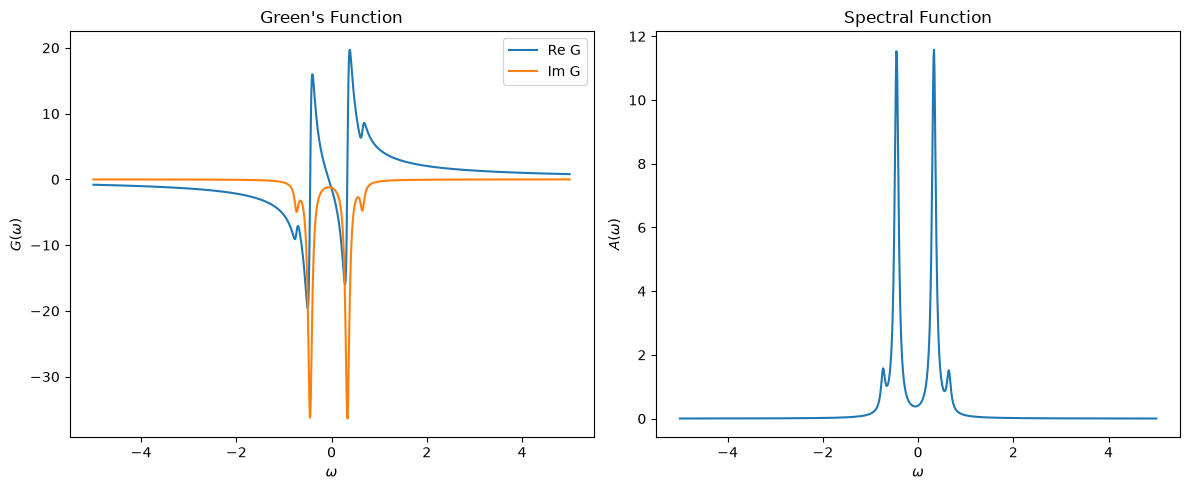

In [4]:
# H2

mol = gto.Mole(
    atom = 'H 0 0 0; H 0 0 1.4', 
    basis = 'sto-3g', # minimal basis set
    spin = 0 # singlet state
)

# perform Hartree-Fock calculation
mf = scf.RHF(mol)
mf.kernel()

engine = RHFSpectralMoments(mf)

pyscf_outputs = engine.pyscf_comparisons()

vqe_outputs = engine.run_vqe(
    max_steps=100,
    stepsize=0.1,
) 

moments = engine.compute_moments(
    theta=vqe_outputs["vqe_params"],
    nmom=5,
)

hole_moments = moments["hole_moments"]
particle_moments = moments["particle_moments"]

gm = engine.galitskii_migdal_energy(hole_moments)


print("")
print('Energy Comparsions')
print("-------------------")
print(f"PySCF Hartree-Fock energy: {pyscf_outputs['hf_energy']:.10f}")
print(f"PySCF FCI energy:        {pyscf_outputs['fci_energy']:.10f}")
if pyscf_outputs["ccsd_energy"] is not None:
    print(f"PySCF CCSD energy:       {pyscf_outputs['ccsd_energy']:.10f}")
print(f"VQE total energy:       {vqe_outputs['vqe_total_energy']:.10f}")
print(f"Galitskii-Migdal energy from moments: {gm['total']:.10f}")

omega_grid = np.linspace(-5, 5, 1000)

gf_data = engine.greens_function_from_moments(
    hole_moments=hole_moments,
    particle_moments=particle_moments,
    omega_grid=omega_grid,
    eta=0.05,
    nblocks=3,
    verbose=False,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Green's function
G_trace = np.trace(
    gf_data["G"],
    axis1=1,
    axis2=2
)

axes[0].plot(
    gf_data["omega"],
    G_trace.real,
    label="Re G"
)

axes[0].plot(
    gf_data["omega"],
    G_trace.imag,
    label="Im G"
)

axes[0].set_xlabel(r"$\omega$")
axes[0].set_ylabel(r"$G(\omega)$")
axes[0].set_title("Green's Function")
axes[0].legend()

# Spectral function
axes[1].plot(
    gf_data["omega"],
    gf_data["A"]
)

axes[1].set_xlabel(r"$\omega$")
axes[1].set_ylabel(r"$A(\omega)$")
axes[1].set_title("Spectral Function")

plt.tight_layout()
plt.show()

converged SCF energy = -1.40288679189723

WARN: RCCSD method does not support ROHF method. ROHF object is converted to UHF object and UCCSD method is called.

E(UCCSD) = -1.496355876884338  E_corr = -0.09346908498710806


Initialize <pyscf.gto.mole.Mole object at 0x11e481f90> in <pyscf.scf.rohf.ROHF object at 0x11e37a7b0>



Energy Comparsions
-------------------
PySCF Hartree-Fock energy: -1.4028867919
PySCF FCI energy:        -1.4963558779
PySCF CCSD energy:       -1.4963558769
VQE total energy:       -1.4959766576
Galitskii-Migdal energy from moments: -1.4959766576


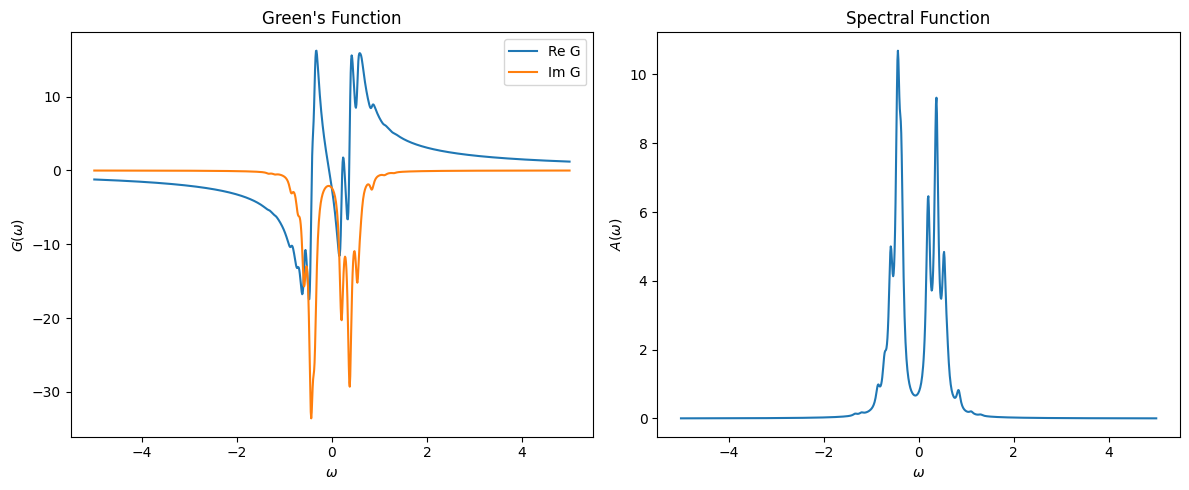

In [4]:
# H3

mol = gto.Mole(
    atom = 'H 0 0 0; H 0 0 1.4; H 0 0 2.8', 
    basis = 'sto-3g', # minimal basis set
    spin = 1 # singlet state
)

# perform Hartree-Fock calculation
mf = scf.RHF(mol)
mf.kernel()

engine = RHFSpectralMoments(mf)

pyscf_outputs = engine.pyscf_comparisons()

vqe_outputs = engine.run_vqe(
    max_steps=100,
    stepsize=0.1,
) 

moments = engine.compute_moments(
    theta=vqe_outputs["vqe_params"],
    nmom=5,
)

hole_moments = moments["hole_moments"]
particle_moments = moments["particle_moments"]

gm = engine.galitskii_migdal_energy(hole_moments)


print("")
print('Energy Comparsions')
print("-------------------")
print(f"PySCF Hartree-Fock energy: {pyscf_outputs['hf_energy']:.10f}")
print(f"PySCF FCI energy:        {pyscf_outputs['fci_energy']:.10f}")
if pyscf_outputs["ccsd_energy"] is not None:
    print(f"PySCF CCSD energy:       {pyscf_outputs['ccsd_energy']:.10f}")
print(f"VQE total energy:       {vqe_outputs['vqe_total_energy']:.10f}")
print(f"Galitskii-Migdal energy from moments: {gm['total']:.10f}")

omega_grid = np.linspace(-5, 5, 1000)

gf_data = engine.greens_function_from_moments(
    hole_moments=hole_moments,
    particle_moments=particle_moments,
    omega_grid=omega_grid,
    eta=0.05,
    nblocks=3,
    verbose=False,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Green's function
G_trace = np.trace(
    gf_data["G"],
    axis1=1,
    axis2=2
)

axes[0].plot(
    gf_data["omega"],
    G_trace.real,
    label="Re G"
)

axes[0].plot(
    gf_data["omega"],
    G_trace.imag,
    label="Im G"
)

axes[0].set_xlabel(r"$\omega$")
axes[0].set_ylabel(r"$G(\omega)$")
axes[0].set_title("Green's Function")
axes[0].legend()

# Spectral function
axes[1].plot(
    gf_data["omega"],
    gf_data["A"]
)

axes[1].set_xlabel(r"$\omega$")
axes[1].set_ylabel(r"$A(\omega)$")
axes[1].set_title("Spectral Function")

plt.tight_layout()
plt.show()

### 3) Statevector simulations to calculate PES for H2 and Hydrogen exchange.

Skipping 4 because I don't have access to a QPU. 

In [ ]:
# H2 pes

r = np.linspace(0.5, 4, 10)
fci_arr = []
ccsd_arr = []
vqe_arr = []
gm_arr = []

for i in range(len(r)):

    mol = gto.Mole(
        atom = 'H 0 0 0; H 0 0 {}'.format(r[i]), 
        basis = 'sto-3g', # minimal basis set
        spin = 0 # singlet state
    )

    # perform Hartree-Fock calculation
    mf = scf.RHF(mol)
    mf.kernel()

    engine = RHFSpectralMoments(mf)

    pyscf_outputs = engine.pyscf_comparisons()

    vqe_outputs = engine.run_vqe(
        max_steps=100,
        stepsize=0.1,
    ) 

    moments = engine.compute_moments(
        theta=vqe_outputs["vqe_params"],
        nmom=5,
    )

    hole_moments = moments["hole_moments"]
    particle_moments = moments["particle_moments"]

    gm = engine.galitskii_migdal_energy(hole_moments)

    fci_arr.append(pyscf_outputs['fci_energy'])
    ccsd_arr.append(pyscf_outputs['ccsd_energy'])
    vqe_arr.append(vqe_outputs['vqe_total_energy'])
    gm_arr.append(gm['total'])

plt.plot(r, fci_arr, label='FCI')
plt.plot(r, ccsd_arr, label='CCSD')
plt.plot(r, vqe_arr, label='VQE')
plt.plot(r, gm_arr, label='Galitskii-Migdal from moments')
plt.xlabel('H-H distance (Anstrom)')
plt.ylabel('Energy (Hartree)')
plt.title('H2 Potential Energy Surface')
plt.legend()
plt.show()

In [ ]:
# ---------- Animation 1: H3 hydrogen exchange ----------
def make_h3_exchange_gif(filename="./h3_hydrogen_exchange.gif"):
    fig, ax = plt.subplots(figsize=(6, 2.5))
    ax.set_xlim(-0.6, 4.6)
    ax.set_ylim(-1.0, 1.0)
    ax.set_aspect("equal")
    ax.axis("off")
    
    # fixed end H atoms, middle H moves from left bond to right bond
    x_left = 0.0
    x_right = 4.0
    x_mid_vals = np.linspace(0.75, 3.25, 60)
    
    points = ax.scatter([], [], s=450)
    labels = []
    bonds = []
    title = ax.text(2.0, 0.75, "", ha="center", fontsize=13)
    
    def init():
        points.set_offsets(np.empty((0, 2)))
        return [points, title]
    
    def update(frame):
        nonlocal labels, bonds
        for t in labels:
            t.remove()
        for b in bonds:
            b.remove()
        labels = []
        bonds = []
        
        x_mid = x_mid_vals[frame]
        xs = np.array([x_left, x_mid, x_right])
        ys = np.array([0.0, 0.0, 0.0])
        points.set_offsets(np.c_[xs, ys])
        
        # draw bonds depending on distance
        if abs(x_mid - x_left) < 1.7:
            bonds.append(ax.plot([x_left, x_mid], [0, 0], lw=3)[0])
        if abs(x_right - x_mid) < 1.7:
            bonds.append(ax.plot([x_mid, x_right], [0, 0], lw=3)[0])
        
        for x, lab in zip(xs, ["H", "H", "H"]):
            labels.append(ax.text(x, -0.45, lab, ha="center", fontsize=12))
        
        title.set_text(r"H + H$_2$ $\rightarrow$ H$_2$ + H exchange coordinate")
        return [points, title] + labels + bonds
    
    anim = FuncAnimation(fig, update, frames=len(x_mid_vals), init_func=init, blit=True)
    anim.save(filename, writer=PillowWriter(fps=12))
    plt.close(fig)
    return filename

h3_path = make_h3_exchange_gif()


h3_path


converged SCF energy = -1.50957465316799

WARN: RCCSD method does not support ROHF method. ROHF object is converted to UHF object and UCCSD method is called.

E(UCCSD) = -1.521738150944472  E_corr = -0.01216349777648449
converged SCF energy = -1.57214447750713

WARN: RCCSD method does not support ROHF method. ROHF object is converted to UHF object and UCCSD method is called.

E(UCCSD) = -1.59711644846279  E_corr = -0.02497197095566097
converged SCF energy = -1.48224245644333

WARN: RCCSD method does not support ROHF method. ROHF object is converted to UHF object and UCCSD method is called.

E(UCCSD) = -1.530698995238727  E_corr = -0.04845653879539839
converged SCF energy = -1.3773514365523

WARN: RCCSD method does not support ROHF method. ROHF object is converted to UHF object and UCCSD method is called.

E(UCCSD) = -1.464454156473566  E_corr = -0.08710271992126238
converged SCF energy = -1.28732665568038

WARN: RCCSD method does not support ROHF method. ROHF object is converted to UHF

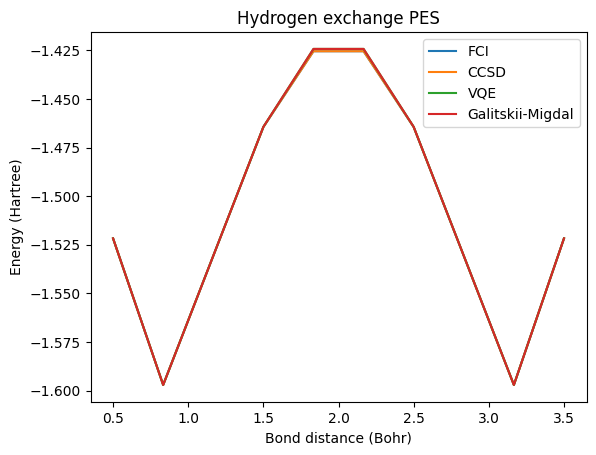

In [5]:
# H3 pes

r = np.linspace(0.5, 3.5, 10)
fci_arr = []
ccsd_arr = []
vqe_arr = []
gm_arr = []

for i in range(len(r)):

    mol = gto.Mole(
        atom='H 0 0 0; H 0 0 {}; H 0 0 4'.format(r[i]),
        basis='sto-3g',
        spin=1,
    )
    mol.build()

    mf = scf.ROHF(mol)
    mf.kernel()

    engine = RHFSpectralMoments(mf)

    pyscf_outputs = engine.pyscf_comparisons()

    vqe_outputs = engine.run_vqe(
        max_steps=100,
        stepsize=0.1,
    ) 

    moments = engine.compute_moments(
        theta=vqe_outputs["vqe_params"],
        nmom=5,
    )

    hole_moments = moments["hole_moments"]
    particle_moments = moments["particle_moments"]

    gm = engine.galitskii_migdal_energy(hole_moments)

    fci_arr.append(pyscf_outputs['fci_energy'])
    ccsd_arr.append(pyscf_outputs['ccsd_energy'])
    vqe_arr.append(vqe_outputs['vqe_total_energy'])
    gm_arr.append(gm['total'])

plt.plot(r, fci_arr, label='FCI')
plt.plot(r, ccsd_arr, label='CCSD')
plt.plot(r, vqe_arr, label='VQE')
plt.plot(r, gm_arr, label='Galitskii-Migdal')
plt.xlabel('Bond distance (Angstroms)')
plt.ylabel('Energy (Hartree)')
plt.title('Hydrogen exchange PES')
plt.legend()
plt.show()

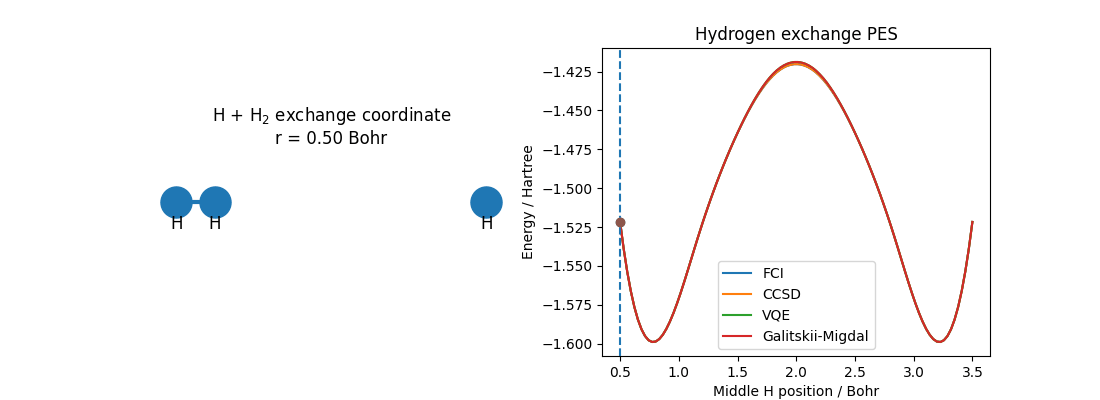

In [11]:
def animate_h3_pes(
    r,
    fci_arr,
    ccsd_arr,
    vqe_arr,
    gm_arr,
    filename="h3_exchange_pes.gif",
    fps=2,
):
    r = np.asarray(r)
    fci_arr = np.asarray(fci_arr)
    ccsd_arr = np.asarray(ccsd_arr)
    vqe_arr = np.asarray(vqe_arr)
    gm_arr = np.asarray(gm_arr)

    fig, (ax_geom, ax_pes) = plt.subplots(
        1, 2, figsize=(11, 4)
    )

    # ---------- geometry panel ----------
    ax_geom.set_xlim(-0.5, 4.5)
    ax_geom.set_ylim(-1.0, 1.0)
    ax_geom.set_aspect("equal")
    ax_geom.axis("off")

    atoms = ax_geom.scatter([], [], s=500)
    bond_left, = ax_geom.plot([], [], lw=3)
    bond_right, = ax_geom.plot([], [], lw=3)
    geom_title = ax_geom.text(
        2.0, 0.75, "", ha="center", fontsize=12
    )

    labels = [
        ax_geom.text(0, 0, "H", ha="center", fontsize=12)
        for _ in range(3)
    ]

    # ---------- PES panel ----------
    ax_pes.plot(r, fci_arr, label="FCI")
    ax_pes.plot(r, ccsd_arr, label="CCSD")
    ax_pes.plot(r, vqe_arr, label="VQE")
    ax_pes.plot(r, gm_arr, label="Galitskii-Migdal")

    marker_line = ax_pes.axvline(r[0], linestyle="--")
    fci_point, = ax_pes.plot([], [], "o")
    vqe_point, = ax_pes.plot([], [], "o")

    ax_pes.set_xlabel("Middle H position / Angstrom")
    ax_pes.set_ylabel("Energy / Hartree")
    ax_pes.set_title("Hydrogen exchange PES")
    ax_pes.legend()

    def update(i):
        x1 = 0.0
        x2 = r[i]
        x3 = 4.0

        xs = np.array([x1, x2, x3])
        ys = np.zeros(3)

        atoms.set_offsets(np.c_[xs, ys])

        for lab, x in zip(labels, xs):
            lab.set_position((x, -0.35))

        # crude bond indicator
        if abs(x2 - x1) < 1.8:
            bond_left.set_data([x1, x2], [0, 0])
        else:
            bond_left.set_data([], [])

        if abs(x3 - x2) < 1.8:
            bond_right.set_data([x2, x3], [0, 0])
        else:
            bond_right.set_data([], [])

        geom_title.set_text(
            f"H + H$_2$ exchange coordinate\nr = {r[i]:.2f} Angstrom"
        )

        marker_line.set_xdata([r[i], r[i]])
        fci_point.set_data([r[i]], [fci_arr[i]])
        vqe_point.set_data([r[i]], [vqe_arr[i]])

        return (
            atoms,
            bond_left,
            bond_right,
            geom_title,
            marker_line,
            fci_point,
            vqe_point,
            *labels,
        )

    anim = FuncAnimation(
        fig,
        update,
        frames=len(r),
        interval=1000 / fps,
        blit=True,
    )

    anim.save(filename, writer=PillowWriter(fps=fps))
    plt.close(fig)

    return filename


r_smooth = np.linspace(r.min(), r.max(), 100)
fci_smooth = interp1d(r, fci_arr, kind="cubic")(r_smooth)
ccsd_smooth = interp1d(r, ccsd_arr, kind="cubic")(r_smooth)
vqe_smooth = interp1d(r, vqe_arr, kind="cubic")(r_smooth)
gm_smooth = interp1d(r, gm_arr, kind="cubic")(r_smooth)

gif_path = animate_h3_pes(
    r_smooth,
    fci_smooth,
    ccsd_smooth,
    vqe_smooth,
    gm_smooth,
    filename="h3_exchange_pes_smooth.gif",
    fps=15,
)

display(Image(filename=gif_path))

### 5) Statevector simulation of Hydrogen attack of Boron Nitrate

In [ ]:
# ---------- Animation 2: BN + H2 approach ----------
def make_bn_h2_attack_gif(filename="./bn_h2_attack.gif"):
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.set_xlim(-4.5, 2.2)
    ax.set_ylim(-1.3, 1.3)
    ax.set_aspect("equal")
    ax.axis("off")
    
    # BN fixed, H2 approaches B side
    x_B = 0.0
    x_N = 1.28
    hh = 0.74
    h2_start = -4.0
    h2_end = -1.25
    h2_positions = np.linspace(h2_start, h2_end, 60)
    
    points = ax.scatter([], [], s=500)
    labels = []
    bonds = []
    title = ax.text(-1.1, 0.95, "", ha="center", fontsize=13)
    
    def init():
        points.set_offsets(np.empty((0, 2)))
        return [points, title]
    
    def update(frame):
        nonlocal labels, bonds
        for t in labels:
            t.remove()
        for b in bonds:
            b.remove()
        labels = []
        bonds = []
        
        x_H1 = h2_positions[frame]
        x_H2 = x_H1 - hh
        
        xs = np.array([x_B, x_N, x_H1, x_H2])
        ys = np.array([0.0, 0.0, 0.0, 0.0])
        points.set_offsets(np.c_[xs, ys])
        
        # BN bond
        bonds.append(ax.plot([x_B, x_N], [0, 0], lw=4)[0])
        # H-H bond
        bonds.append(ax.plot([x_H1, x_H2], [0, 0], lw=3)[0])
        # weak interaction / attack line when close
        if abs(x_H1 - x_B) < 2.0:
            bonds.append(ax.plot([x_H1, x_B], [0, 0], lw=2, linestyle="--")[0])
        
        for x, lab in zip(xs, ["B", "N", "H", "H"]):
            labels.append(ax.text(x, -0.48, lab, ha="center", fontsize=12))
        
        title.set_text(r"BN $\cdots$ H$_2$ approach / hydrogen attack coordinate")
        return [points, title] + labels + bonds
    
    anim = FuncAnimation(fig, update, frames=len(h2_positions), init_func=init, blit=True)
    anim.save(filename, writer=PillowWriter(fps=12))
    plt.close(fig)
    return filename

bn_h2_path = make_bn_h2_attack_gif()
bn_h2_path

In [ ]:
ncas = 3
nelecas = 4


def build_bn_h2_active_space(
    basis="sto-3g",
    bn_bond=1.281,
    hh_bond=0.741,
    h2_distance=2.0,
    ncas=3,
    nelecas=4,
):
    """
    Minimal BN + H2 coating-fragment toy model.

    Interpretation:
    - BN represents a tiny boron-nitride ceramic/coating motif.
    - H2 approaches the B site along the molecular axis.
    - h2_distance controls BN...H2 separation.

    ncas = 3 -> 6 qubits
    nelecas = 4 -> CAS(4e,3o)
    """

    mol = gto.Mole()
    mol.atom = f"""
    B   0.000000   0.000000   0.000000
    N   0.000000   0.000000   {bn_bond}

    H   0.000000   0.000000   {-h2_distance}
    H   0.000000   0.000000   {-h2_distance - hh_bond}
    """
    mol.basis = basis
    mol.charge = 0
    mol.spin = 0
    mol.unit = "Angstrom"
    mol.build()

    mf = scf.RHF(mol)
    mf.kernel()

    if not mf.converged:
        raise RuntimeError("RHF did not converge")

    mc = mcscf.CASCI(mf, ncas, nelecas)

    h1eff, ecore = mc.get_h1eff()
    eri_cas = mc.get_h2eff()
    eri_cas = ao2mo.restore(1, eri_cas, ncas)

    return mol, mf, mc, h1eff, ecore, eri_cas


mol, mf, mc, h1eff, ecore, eri_cas = build_bn_h2_active_space()

print("Total electrons:", mol.nelectron)
print("HF energy:", mf.e_tot)
print("ecore:", ecore)
print("h1eff shape:", h1eff.shape)
print("eri_cas shape:", eri_cas.shape)
print("n qubits:", 2 * h1eff.shape[0])


In [ ]:
ecas_arr = []
for r in [3.0, 2.5, 2.0, 1.7, 1.5, 1.3]:
    mol, mf, mc, h1eff, ecore, eri_cas = build_bn_h2_active_space(
        h2_distance=r,
        ncas=3,
        nelecas=4,
    )

    e_cas = mc.kernel()[0]
    ecas_arr.append(e_cas)

    print(
        f"H2 distance = {r:4.2f} Å | "
        f"HF = {mf.e_tot:.10f} | "
        f"CASCI = {e_cas:.10f} | "
        f"corr = {e_cas - mf.e_tot:.10f}"
    )

plt.plot(
    [3.0, 2.5, 2.0, 1.7, 1.5, 1.3],
    ecas_arr,
    marker="o",
)
plt.xlabel("H2 distance from BN (Å)")
plt.ylabel("CASCI Energy (Hartree)")
plt.title("BN + H2 Active Space Energy vs. Separation")
plt.show()

In [ ]:
def build_bn_h_active_space(
    basis="sto-3g",
    bn_bond=1.281,
    h_distance=1.5,
    ncas=3,
    nelecas=(3, 2),
):
    """
    BN + H radical model.

    Total electrons:
    B = 5, N = 7, H = 1 -> 13 electrons.
    Open-shell doublet.

    ncas = 3 -> 6 qubits
    nelecas = (3, 2) -> 5 active electrons
    """

    mol = gto.Mole()
    mol.atom = f"""
    B   0.000000   0.000000   0.000000
    N   0.000000   0.000000   {bn_bond}
    H   0.000000   0.000000   {-h_distance}
    """
    mol.basis = basis
    mol.charge = 0
    mol.spin = 1       # doublet: N_alpha - N_beta = 1
    mol.unit = "Angstrom"
    mol.build()

    mf = scf.ROHF(mol)
    mf.kernel()

    if not mf.converged:
        raise RuntimeError("ROHF did not converge")

    mc = mcscf.CASCI(mf, ncas, nelecas)

    h1eff, ecore = mc.get_h1eff()
    eri_cas = mc.get_h2eff()
    eri_cas = ao2mo.restore(1, eri_cas, ncas)

    return mol, mf, mc, h1eff, ecore, eri_cas